In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa

## MFCCs: Extracting and Storing Features for All Songs

In [25]:
#Define audio directory
AI_audio_dir = 'data/AI'

#List of all the AI audio files
AI_audio_files = os.listdir(AI_audio_dir)

In [ ]:
# Function to extract MFCC features and calculate the mean
def extract_mfcc_mean(file_path):
    """Extracts MFCC features and computes the mean."""
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, mono=True, duration=30)
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=y, sr=sr)
        # Compute the mean of the MFCCs across all frames
        mfccs_mean = np.mean(mfccs.T, axis=0)
        return mfccs_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists to store data
AI_mfccs_list = []
song_names = []

# Loop through each file in the directory
for filename in AI_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(AI_audio_dir, filename)
        mfcc_features = extract_mfcc_mean(file_path)
        
        if mfcc_features is not None:
            AI_mfccs_list.append(mfcc_features)
            song_names.append(filename)

# Create a pandas DataFrame
# Each row will be a song, and each column an MFCC feature
AI_mfccs_df = pd.DataFrame(AI_mfccs_list)

# Set the song filenames as the index for easier identification
AI_mfccs_df.index = song_names

# Add column names for the MFCC coefficients
# Assuming 20 MFCCs are returned by default by librosa
AI_mfccs_df.columns = [f'mfcc_{i}' for i in range(AI_mfccs_df.shape[1])]

# Display the resulting DataFrame
print(AI_mfccs_df.head())

# DataFrame to a CSV file
AI_mfccs_df.to_csv('AI_mfcc_features.csv')


                                       mfcc_0      mfcc_1     mfcc_2  \
Prank Call.mp3                    -176.381332  131.804886  15.888794   
Sushi.mp3                         -226.069473  115.499107   3.231841   
Candyland.mp3                     -109.165680   91.074059  -7.206758   
Missus Ego.mp3                    -102.586250   66.706703   9.687790   
All You Need Is a Better Song.mp3 -168.648560  107.571083  13.430568   

                                      mfcc_3     mfcc_4     mfcc_5    mfcc_6  \
Prank Call.mp3                     34.943951  10.436429   7.278682  6.794213   
Sushi.mp3                          21.050531  -5.037582 -14.919394 -2.997003   
Candyland.mp3                      33.477066  -5.675916   0.873547  9.736558   
Missus Ego.mp3                     13.000587   2.328208  -5.981337  3.753094   
All You Need Is a Better Song.mp3  19.681698  -2.983643  -1.723100 -5.345958   

                                     mfcc_7    mfcc_8    mfcc_9    mfcc_10  \
Prank Ca

## Tempogram: Extracting and Storing Features for All Songs

In [ ]:
# Function to extract tempo
def extract_tempo(file_path):
    """Extracts the estimated tempo (BPM) from an audio file."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        return tempo
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize
AI_tempo_list = []
song_names = []

# Loop through each file
for filename in AI_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(AI_audio_dir, filename)
        tempo = extract_tempo(file_path)

        if tempo is not None:
            AI_tempo_list.append(tempo)
            song_names.append(filename)

# Create DataFrame
AI_tempo_df = pd.DataFrame({'song_name': song_names, 'tempo_bpm': AI_tempo_list})
AI_tempo_df.set_index('song_name', inplace=True)

# Display
print(AI_tempo_df.head())

# Save to CSV
AI_tempo_df.to_csv('AI_tempo_features.csv')

                                             tempo_bpm
song_name                                             
Prank Call.mp3                            [172.265625]
Sushi.mp3                             [161.4990234375]
Candyland.mp3                             [86.1328125]
Missus Ego.mp3                     [89.10290948275862]
All You Need Is a Better Song.mp3         [103.359375]


## Chroma: Extracting and Storing Features for All Songs

In [32]:
# Function to extract chroma features and compute their mean
def extract_chroma_mean(file_path):
    """Extracts chroma features and computes their mean across frames."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        S = np.abs(librosa.stft(y, n_fft=4096))**2
        chroma = librosa.feature.chroma_stft(S=S, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        return chroma_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists
AI_chroma_list = []
song_names = []

# Loop through files
for filename in AI_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(AI_audio_dir, filename)
        chroma_features = extract_chroma_mean(file_path)

        if chroma_features is not None:
            AI_chroma_list.append(chroma_features)
            song_names.append(filename)

# Create DataFrame
AI_chroma_df = pd.DataFrame(AI_chroma_list, index=song_names)
AI_chroma_df.columns = [f'chroma_{i}' for i in range(AI_chroma_df.shape[1])]

# Display
print(AI_chroma_df.head())

# Save to file
AI_chroma_df.to_csv('AI_chroma_features.csv')

                                   chroma_0  chroma_1  chroma_2  chroma_3  \
Prank Call.mp3                     0.360693  0.214544  0.302494  0.344741   
Sushi.mp3                          0.234808  0.229990  0.455423  0.315539   
Candyland.mp3                      0.340102  0.378528  0.577597  0.358455   
Missus Ego.mp3                     0.302906  0.331493  0.430089  0.249976   
All You Need Is a Better Song.mp3  0.583974  0.333202  0.371061  0.265404   

                                   chroma_4  chroma_5  chroma_6  chroma_7  \
Prank Call.mp3                     0.187983  0.279832  0.177689  0.341354   
Sushi.mp3                          0.191316  0.254460  0.204522  0.396826   
Candyland.mp3                      0.285621  0.319447  0.309523  0.312706   
Missus Ego.mp3                     0.214616  0.417197  0.295135  0.245266   
All You Need Is a Better Song.mp3  0.414953  0.517735  0.243011  0.273351   

                                   chroma_8  chroma_9  chroma_10  chroma_1

## Concat All AI_DFs

In [46]:
# --- Load feature DataFrames ---
mfcc_df = pd.read_csv('AI_mfcc_features.csv', index_col=0)
tempo_df = pd.read_csv('AI_tempo_features.csv', index_col=0)
chroma_df = pd.read_csv('AI_chroma_features.csv', index_col=0)

# Load metadata (columns: song_name, song_prompt)
metadata_df = pd.read_csv('AI_set.csv', sep=";")

# --- Clean up names ---
mfcc_df.index = mfcc_df.index.str.replace('.mp3', '', regex=False)
tempo_df.index = tempo_df.index.str.replace('.mp3', '', regex=False)
chroma_df.index = chroma_df.index.str.replace('.mp3', '', regex=False)
metadata_df['song_name'] = metadata_df['song_name'].str.replace('.mp3', '', regex=False)

# --- Combine feature DataFrames (keeping song_name as index) ---
combined_features_df = mfcc_df.join(tempo_df, how='outer')
combined_features_df = combined_features_df.join(chroma_df, how='outer')

# --- Merge with metadata ---
# Since combined_features_df uses song_name as index, merge on index
final_df = metadata_df.merge(combined_features_df, left_on='song_name', right_index=True, how='left')

# --- Reorder columns ---
ordered_cols = (
    ['song_name', 'song_prompt'] +
    [col for col in final_df.columns if col.startswith('mfcc_')] +
    ['tempo_bpm'] +
    [col for col in final_df.columns if col.startswith('chroma_')]
)
final_df = final_df[ordered_cols]

# --- Save ---
final_df.to_csv('AI_full_audio_features.csv', index=False)
print("✅ Final combined DataFrame saved to 'AI_full_audio_features.csv'")

# Preview
print(final_df.head())


✅ Final combined DataFrame saved to 'AI_full_audio_features.csv'
                              song_name  \
0  they-built-the-ship-titanic-id-4f8c5   
1                lizard-lounge-id-863a8   
2        drinks-in-the-kitchen-id-33978   
3                     lemonade-id-8baf6   
4             cardboard-cutout-id-8bd10   

                                         song_prompt  mfcc_0  mfcc_1  mfcc_2  \
0       Simple video game song about sunday cleaning     NaN     NaN     NaN   
1         Melancholy up tempo song about fresh paint     NaN     NaN     NaN   
2                   Smooth dj song about street cats     NaN     NaN     NaN   
3   Danceable slow rap song about your childhood ...     NaN     NaN     NaN   
4    Synth-driven reverb song about making playlists     NaN     NaN     NaN   

   mfcc_3  mfcc_4  mfcc_5  mfcc_6  mfcc_7  ...  chroma_2  chroma_3  chroma_4  \
0     NaN     NaN     NaN     NaN     NaN  ...       NaN       NaN       NaN   
1     NaN     NaN     NaN     NaN  

In [26]:
librosa.feature.chroma_stft(y=y, sr=sr)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(12, 7944), dtype=float32)

In [30]:
S = np.abs(librosa.stft(y, n_fft=4096))**2
librosa.util.normalize(S)
chroma = librosa.feature.chroma_stft(S=S, sr=sr)
chroma

array([[0.        , 0.        , 0.705472  , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.86199296, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.84597313, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.7884096 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.5828074 , ..., 0.        , 0.        ,
        0.        ]], shape=(12, 3972), dtype=float32)

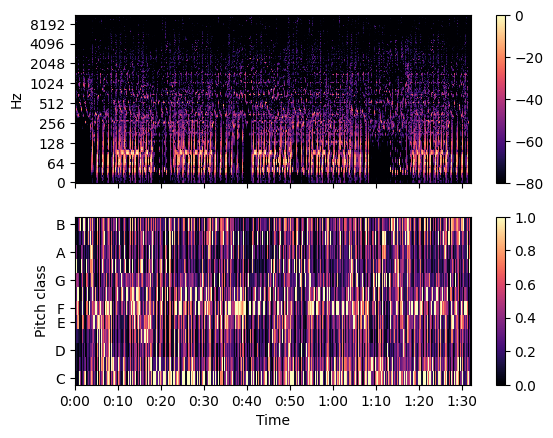

In [31]:
fig, ax = plt.subplots(nrows=2, sharex=True)
img = librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max),
                               y_axis='log', x_axis='time', ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].label_outer()
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])

In [ ]:
"""
https://colab.research.google.com/drive/1SF0PagTlBzywYqyGYiBT4ASaSKCw9Sc_

def create_graph_from_audio(song_path):
    print(f"Creating graph for: {song_path}")
    # In a real-world application, this function would process the audio file
    # (e.g., using libraries like Librosa) and build a graph based on its features.
    return nx.Graph()

song_path = "data/Spotify/"
song_files = [os.path.join(song_path, f) for f in os.listdir(song_path) if f.endswith('.mp3')]

song_graphs_generator = (create_graph_from_audio(song_path) for song_path in song_files)

# This does not store all graphs at once. You can iterate through them as needed.
for graph in song_graphs_generator:
    # Process each graph individually
    print(f"Processing a graph: {graph}")
"""